# **TFM Project - Machine Learning for Drug Discovery in Neurodegenerative Diseases**
# **[Part 8] XAI**

Carla D. Di Monno

In **Part 8**, bioactivity (pchembl_value) for target is predicted using the corresponding optimised XGBoost regression model, and the importance of the features is interpreted using both the model’s direct importance and SHAP values.                                               

---

## **Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import shap
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report

from google.colab import files

In [ ]:
def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)
    return df, fn

## **Load the dataset and pre-processing**

In [ ]:
# Upload dataset ({target}_bioactivity_data_Pubchem-fp_wo_filtered.csv)
df, uploaded_filename = upload_files()
print(df.shape)
df.head()

Saving LRRK2_WT_bioactivity_data_Pubchem-fp_wo_filtered.csv to LRRK2_WT_bioactivity_data_Pubchem-fp_wo_filtered.csv
User uploaded file "LRRK2_WT_bioactivity_data_Pubchem-fp_wo_filtered.csv" with length 1360020 bytes
(1297, 520)


,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP15,PubchemFP16,PubchemFP17,PubchemFP18,PubchemFP19,PubchemFP20,...,PubchemFP833,PubchemFP834,PubchemFP840,PubchemFP842,PubchemFP854,PubchemFP860,PubchemFP863,PubchemFP868,bioactivity_class,pchembl_value
0,1,1,0,1,1,1,0,1,1,0,...,1,0,0,0,0,0,0,0,1,7.800000
1,1,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,1,8.003750
2,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,1,7.823333
3,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,1,7.660000
4,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,1,7.290000


In [ ]:
target_name = uploaded_filename.replace('_bioactivity_data_Pubchem-fp_wo_filtered.csv', '')

In [ ]:
df.shape

(1297, 520)

In [ ]:
X = df.drop(['bioactivity_class','pchembl_value'], axis=1)
X

,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP15,PubchemFP16,PubchemFP17,PubchemFP18,PubchemFP19,PubchemFP20,...,PubchemFP830,PubchemFP831,PubchemFP833,PubchemFP834,PubchemFP840,PubchemFP842,PubchemFP854,PubchemFP860,PubchemFP863,PubchemFP868
0,1,1,0,1,1,1,0,1,1,0,...,0,0,1,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,1,1,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1293,1,1,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1294,1,1,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1295,1,1,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Y = df['pchembl_value']
Y

,pchembl_value
0,7.800000
1,8.003750
2,7.823333
3,7.660000
4,7.290000
...,...
1292,8.640000
1293,8.650000
1294,8.430000
1295,8.470000


### **Remove low variance features**

In [ ]:
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [ ]:
X.shape

(1297, 133)

## **Data split (train/test): 80/20 ratio**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} records")
print(f"Test: {X_test.shape[0]} records")

Train: 1037 records
Test: 260 records


## **Building a Regression Model using XGBoost**

In [ ]:
best_params = {
    #'n_estimators': 288, 'max_depth': 6, 'learning_rate': 0.04637732989546737, 'subsample': 0.8337382418893292
    'n_estimators': 563, 'max_depth': 4, 'learning_rate': 0.03855213395429509, 'subsample': 0.7095194370166913
}

In [ ]:
model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03855213395429509, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=563, n_jobs=-1,
             num_parallel_tree=None, ...)

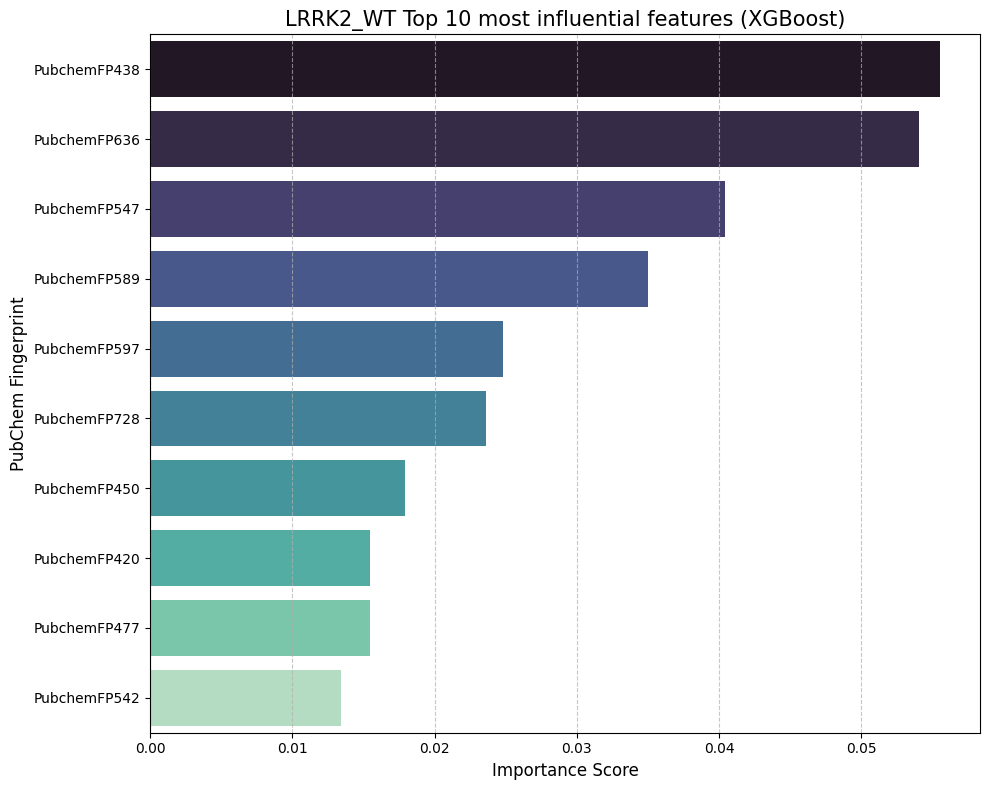


List of the 10 most important bits:
          Feature  Importance
48   PubchemFP438    0.055581
100  PubchemFP636    0.054040
74   PubchemFP547    0.040427
87   PubchemFP589    0.035031
90   PubchemFP597    0.024825
127  PubchemFP728    0.023617
51   PubchemFP450    0.017948
43   PubchemFP420    0.015445
56   PubchemFP477    0.015422
73   PubchemFP542    0.013440


In [ ]:
# --- A. FEATURE IMPORTANCE ---
importance = model.feature_importances_
feature_names = selection.get_feature_names_out()

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

top_10 = df_importance.head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_10,
    hue='Feature',
    palette='mako',
    legend=False
)
plt.title(f'{target_name} Top 10 most influential features (XGBoost)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('PubChem Fingerprint', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{target_name}_Top-10_influential_features_XGBoost.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nList of the 10 most important bits:")
print(top_10)

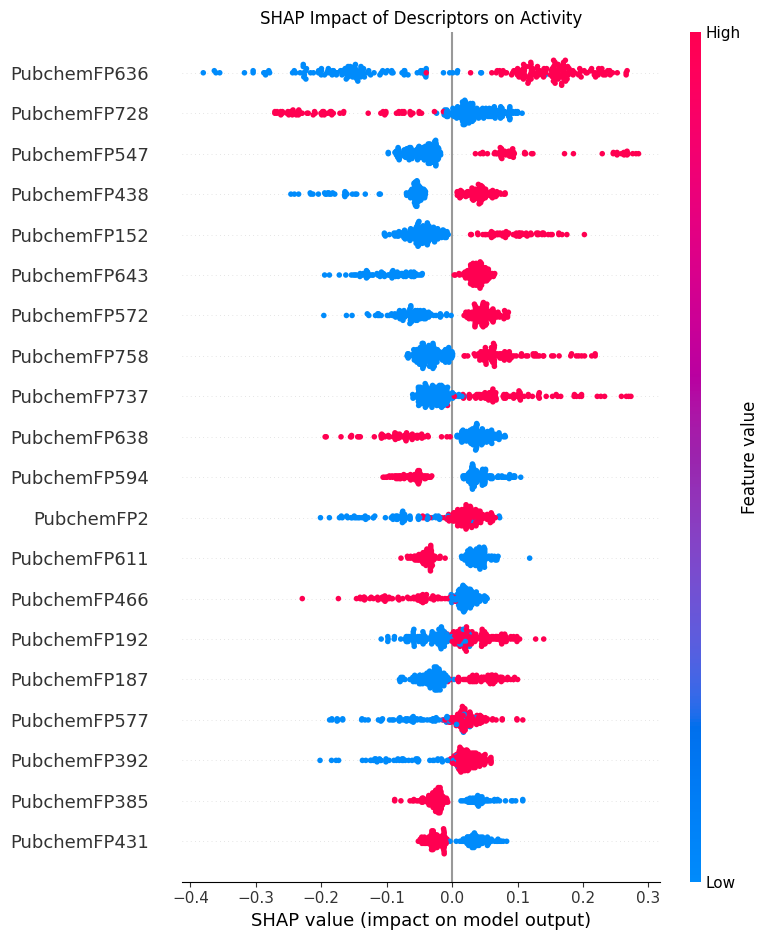

In [ ]:
# --- B. SHAP VALUES ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="dot", show=False)
plt.title(f"SHAP Impact of Descriptors on Activity")
plt.tight_layout()
plt.savefig(f'{target_name}_SHAP_impact_features_XGBoost.png', dpi=300, bbox_inches='tight')
plt.show()